In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [11]:
np.random.seed(42)

n=200

area = np.random.randint(50, 251, n)
rooms = np.random.randint(1,6,n)
age = np.random.randint(0, 31, n)
distance = np.random.uniform(1, 20, n)

noise = np.random.normal(0, 0.5, n)

price=(
    0.04 * area
   +0.05 * rooms
   -0.8  * age
   -0.15 * distance
   +noise
)

df = pd.DataFrame({
    "Area" : area,
    "Rooms": rooms,
    "Age"  : age,
    "Distance" : distance,
    "Price": price
})

df.head()

,Area,Rooms,Age,Distance,Price
0,152,1,22,1.205915,-11.622150
1,229,4,7,18.202258,-0.111740
2,142,1,19,2.734447,-9.931142
3,64,1,15,7.066959,-10.428977
4,156,2,12,19.051177,-5.860382


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Area      200 non-null    int32  
 1   Rooms     200 non-null    int32  
 2   Age       200 non-null    int32  
 3   distance  200 non-null    float64
 4   Price     200 non-null    float64
dtypes: float64(2), int32(3)
memory usage: 5.6 KB


In [5]:
df.isnull().sum()

Area        0
Rooms       0
Age         0
distance    0
Price       0
dtype: int64

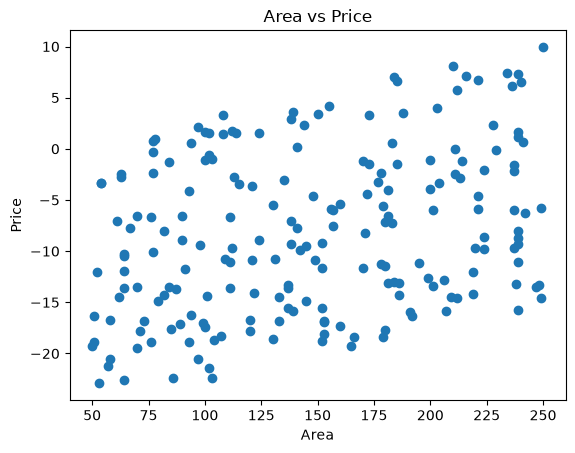

In [7]:
plt.scatter(df["Area"],df["Price"])
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Area vs Price")

plt.show()

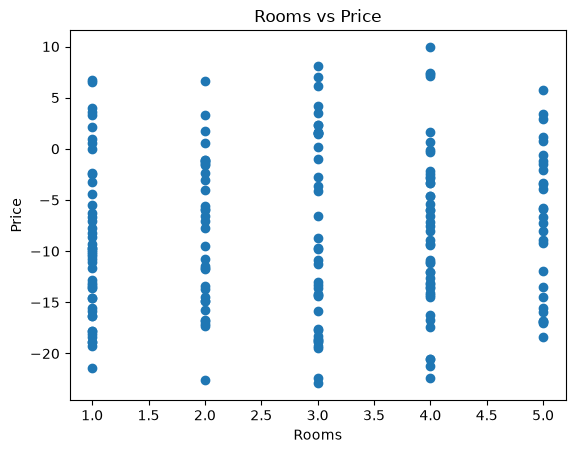

In [8]:
plt.scatter(df["Rooms"],df["Price"])
plt.xlabel("Rooms")
plt.ylabel("Price")
plt.title("Rooms vs Price")

plt.show()

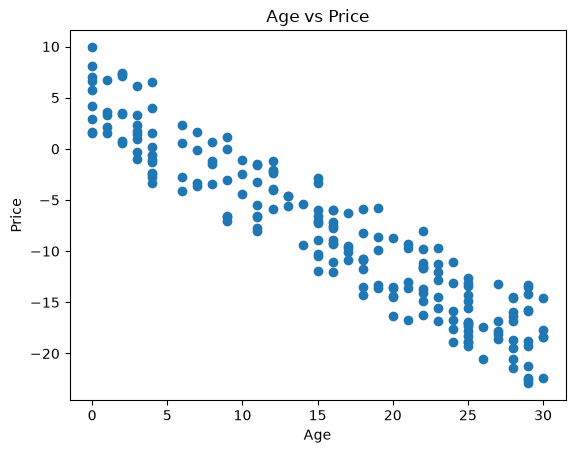

In [9]:
plt.scatter(df["Age"],df["Price"])
plt.xlabel("Age")
plt.ylabel("Price")
plt.title("Age vs Price")

plt.show()

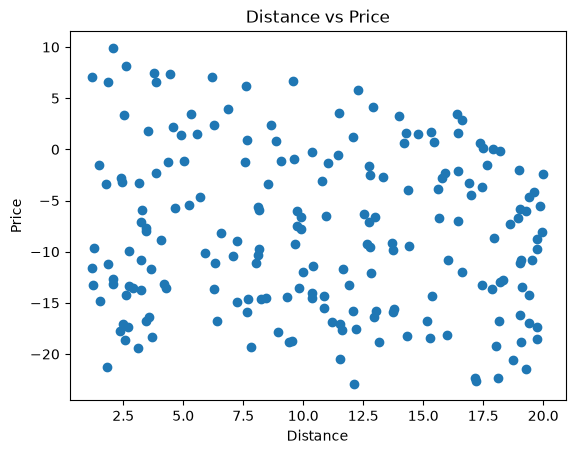

In [12]:
plt.scatter(df["Distance"],df["Price"])
plt.xlabel("Distance")
plt.ylabel("Price")
plt.title("Distance vs Price")

plt.show()

In [13]:
correlation = df.corr()
print(correlation)

              Area     Rooms       Age  Distance     Price
Area      1.000000  0.017042 -0.006788 -0.117840  0.319270
Rooms     0.017042  1.000000 -0.065965  0.020265  0.066232
Age      -0.006788 -0.065965  1.000000 -0.032661 -0.941567
Distance -0.117840  0.020265 -0.032661  1.000000 -0.111429
Price     0.319270  0.066232 -0.941567 -0.111429  1.000000


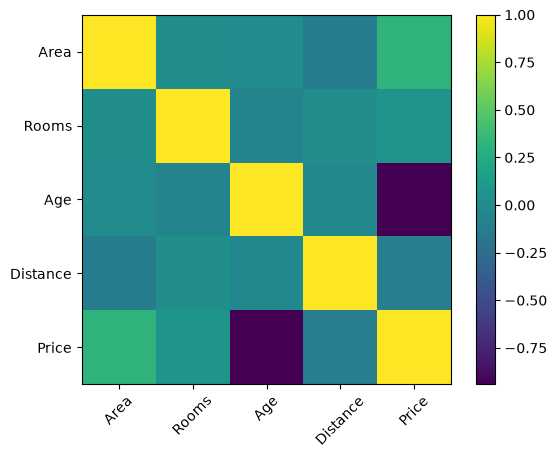

In [16]:
import matplotlib.pyplot as plt
plt.imshow(correlation)

plt.xticks(range(len(correlation.columns)),
correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)),
correlation.columns)

plt.colorbar()
plt.show()


In [17]:
x = df[["Area", "Rooms", "Age", "Distance"]]
y = df["Price"]



In [18]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state = 42
)

In [19]:
model = LinearRegression()

In [20]:
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 0.04, 0.02,-0.8 ,-0.15]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['Area','Rooms','Age','Distance']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.1583
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [21]:
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [ 0.03935201  0.02323431 -0.80113477 -0.1463285 ]
Intercept: 0.1583489938290672


In [24]:
y_pred = model.predict(x_test)
print(y_pred[:10])

[  3.95861285 -12.31370058   3.27380036 -17.44070371  -6.94289397
 -13.78519945  -3.73525735  -7.26354859  -3.7900753   -0.39028833]


In [25]:
comparison = pd.DataFrame({
    "Actual:" : y_test.values,
    "Predicted" : y_pred
})

print(comparison.head(10))

     Actual:  Predicted
0   3.982543   3.958613
1 -13.366002 -12.313701
2   2.891086   3.273800
3 -17.582689 -17.440704
4  -6.697893  -6.942894
5 -14.256029 -13.785199
6  -2.830514  -3.735257
7  -7.265889  -7.263549
8  -4.167136  -3.790075
9  -1.113857  -0.390288


In [26]:
mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 0.2913721034986375


In [27]:
r2 = r2_score(y_test, y_pred)
print("r2:", r2)

r2: 0.9947354162823119


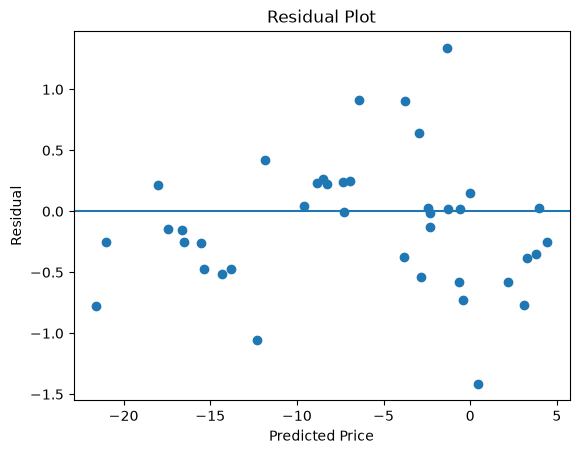

In [28]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)

plt.axhline(0)

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()